In [4]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline, PchipInterpolator, UnivariateSpline, Akima1DInterpolator
from matplotlib import pyplot as plt
import pprint as pprint
#import papermill as pm
import scrapbook as sb
from Utils import ReadTheCsv,ReadTheSpill,append_to_dict

class bcolors:
    OK = "\033[92m"  # GREEN
    WARNING = "\033[93m"  # YELLOW
    FAIL = "\033[91m"  # RED
    RESET = "\033[0m"  # RESET COLOR

In [5]:
!pip install scrapbook
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [6]:
CutsType = "CutsType2"
run_to_analyze = "ag14235/ag14235.vertex.csv"
bkg_up = 0.0010
bkg_down = 0.0008

In [7]:
runs = {"2025": [run_to_analyze]}

mirG_center = -415 # <----
mirA_center = -671 # <----
zmin = mirA_center - 200 # <----
zgap_min = mirA_center # <----
zmax = mirG_center + 200 # <----
zgap_max = mirG_center # <----

class Zcuts:
    def __init__(self,a,b):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a

ZCUTS = Zcuts(-415,-671)

# estimate background

In [8]:
if(True): # < ----
    datacosm = ReadTheCsv("ag13628/ag13628.vertex.csv",  "-1", zmin, zmax, CutsType)
    mask_down = (datacosm["Z"] < zgap_min)
    bkg_down = (mask_down.sum())/6668
    mask_up = (datacosm["Z"] > zgap_max)
    bkg_up = (mask_up.sum())/6668
    print(f"Bkg estimated: up region {bkg_up:.4f} Hz down region {bkg_down:.4f} Hz")

Bkg estimated: up region 0.0010 Hz down region 0.0009 Hz


In [9]:
data = ReadTheCsv(runs["2025"][0],  "-1", zmin, zmax, CutsType)

# Microwave DUMP
mw_cb_start, mw_cb_stop = ReadTheSpill(runs["2025"][0], "\"Microwave Dump\"[0]")

# First round laser Cooling
#first_LC_start, first_LC_stop = ReadTheSpill2(runs["2025"][0],"Lyman Alpha") # Work In Progress

# Second Round Laser Cooling
#second_LC_start, second_LC_stop = ReadTheSpill2(runs["2025"][0],"\"Adiabatic Expansion\"[0]") # Work in Progress

# PreGravityWell
pregravity_start, pregravity_stop = ReadTheSpill(runs["2025"][0], "\"PreGravityWell\"[0]")

# Initial OcB Ramp Down
InitOcB_start, InitOcB_stop = ReadTheSpill(runs["2025"][0], "\"Initial OcB Ramp Down\"[0]")

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill(runs["2025"][0], "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill(runs["2025"][0], "\"WaitForQuasitrapped\"[1]")

# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[2]")

# Oc RampDown
Oc_start_rampdown, Oc_stop_rampdown = ReadTheSpill(runs["2025"][0],"\"Oc RampDown\"[0]")

# Porch
start_RampAllFinalStep, stop_RampAllFinalStep = ReadTheSpill(runs["2025"][0],"\"RampAllFinalStep\"[0]")

print(mw_cb_start)

ag14235/ag14235.vertex.csv
ag14235/ag14235.vertex.csv
   [9755.358-9856.461]= 101.103s |          "PreGravityWell"[0]         |    9791      514      481      317     4926     3774    11361     9221    21417       490 

ag14235/ag14235.vertex.csv
   [9876.710-9977.813]= 101.103s |          "Initial OcB Ramp Down"[0]  |    9961      457      515      356     4990     3769    11147     7927    20167       133 

ag14235/ag14235.vertex.csv
   [9998.313-10098.316]= 100.003s |          "WaitForQuasitrapped"[0]    |    9693      481      465      331     4826     3694    11151     7335    19298        18 

ag14235/ag14235.vertex.csv
   [10607.019-11207.027]= 600.007s |          "WaitForQuasitrapped"[1]    |   58317     3027     2991     1950    28864    22030    66166    45501   116313        96 

ag14235/ag14235.vertex.csv
   [10209.055-10220.257]=  11.202s |          "MBMF RampDown"[0]          |    1124       53       60       37      570      441     1236      819     2312         2 

ag1

[100]
0.04393159718056508
22.53353000000061
bin time 22.53353000000061
[ 3.70745504e+06  1.34754580e+01 -7.30972554e+05]
something wrong


/tmp/ipykernel_2204/4245459316.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcovm = curve_fit(exponential, edges[mask_fit],  TOT_RUN_counts[mask_fit], p0 = [100, 20, stop_mbmf_rampdown2[0]])


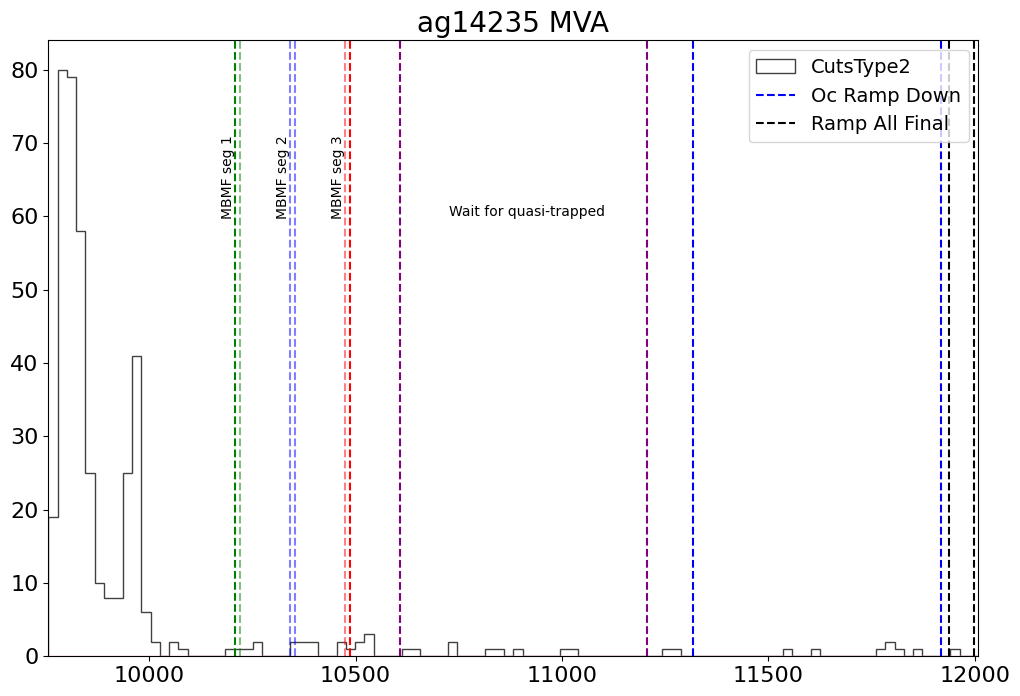

In [10]:
binning = np.array([100])
print(binning)

plt.figure(0, figsize = (12, 8))
plt.title(f"ag{runs['2025'][0].split('/')[0].replace('ag','')} MVA", fontsize = 20)
plt.yticks(fontsize = 16)
plt.xticks(fontsize = 16)
#plt.ylim(0,30)
plt.xlim(pregravity_start[0], stop_RampAllFinalStep[0] + 10)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (pregravity_start[0], stop_RampAllFinalStep[0] + 10) , histtype = "step", color = "black", density = False, label = f"{CutsType}", alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

#### FIT BOIL UP DATA
edges = edges[0:-1] + np.diff(edges)[0]
mask_fit = (edges > stop_mbmf_rampdown2[0] + 50) & (edges < waitForQuasiTrapped_stop1[0] )
def exponential(x, N, tau, t0):
    return N * np.exp(-(x - t0)/tau)

popt, pcovm = curve_fit(exponential, edges[mask_fit],  TOT_RUN_counts[mask_fit], p0 = [100, 20, stop_mbmf_rampdown2[0]])

errorttau = np.sqrt(pcovm.diagonal()[1])
print(popt)

try:
    plt.plot(edges[mask_fit], exponential(edges[mask_fit], *popt), marker = '', color = 'red', linestyle = "--", label = f" tau = {int(popt[1])} +/- {int(errorttau)} s")
except:
    print("something wrong")
#plt.axvline(mw_cb_start[0], linestyle = "--", color = "orange", label = "start cb sweep")
#plt.axvline(mw_cb_stop[0], linestyle = "--", color = "orange", label = "stop cb sweep")

#plt.axvline(first_LC_start[0], linestyle = "--", color = "blue", label = "Laser Cooling")
#plt.axvline(first_LC_stop[0], linestyle = "--", color = "blue")

#plt.axvline(InitOcB_start[0], linestyle = "--", color = "red", label = "Initial OcB ramp down")
#plt.axvline(InitOcB_stop[0], linestyle = "--", color = "red")

#plt.axvline(waitForQuasiTrapped_start[0], linestyle = "--", color = "purple", label = "Wait For QuasiTrapped")
#plt.axvline(waitForQuasiTrapped_stop[0], linestyle = "--", color = "purple")

plt.axvline(waitForQuasiTrapped_start1[0], linestyle = "--", color = "purple")
plt.axvline(waitForQuasiTrapped_stop1[0], linestyle = "--", color = "purple")
plt.text((waitForQuasiTrapped_start1[0] + waitForQuasiTrapped_stop1[0])/2 - 180, maxbin - 20, "Wait for quasi-trapped")

plt.axvline(start_mbmf_rampdown0[0], linestyle = "--", color = "green")
plt.axvline(stop_mbmf_rampdown0[0], linestyle = "--", color = "green", alpha = 0.5)
plt.text(start_mbmf_rampdown0[0] - 35, maxbin - 20, "MBMF seg 1",rotation = 90)

plt.axvline(start_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.text(start_mbmf_rampdown1[0] - 35, maxbin - 20, "MBMF seg 2",rotation = 90)

plt.axvline(start_mbmf_rampdown2[0], linestyle = "--", color = "red", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown2[0], linestyle = "--", label = "", color = "red")
plt.text(start_mbmf_rampdown2[0] - 35, maxbin - 20, "MBMF seg 3",rotation = 90)

plt.axvline(Oc_start_rampdown[0], linestyle = "--", label = "Oc Ramp Down", color = "blue")
plt.axvline(Oc_stop_rampdown[0], linestyle = "--", label = "", color = "blue")

plt.axvline(start_RampAllFinalStep[0], linestyle = "--", label = "Ramp All Final", color = "black")
plt.axvline(stop_RampAllFinalStep[0], linestyle = "--", label = "", color = "black")

#plt.ylim(0,30)

plt.legend( fontsize = 14, loc = "upper right")
plt.savefig(f"Summary_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

[40]
0.0009846505698855462
0.5050499999997555
bin time 0.5050499999997555
0.0009846505698855462
0.5050499999997555
bin time 0.5050499999997555
0.0009846505698855462
0.5050499999997555
bin time 0.5050499999997555


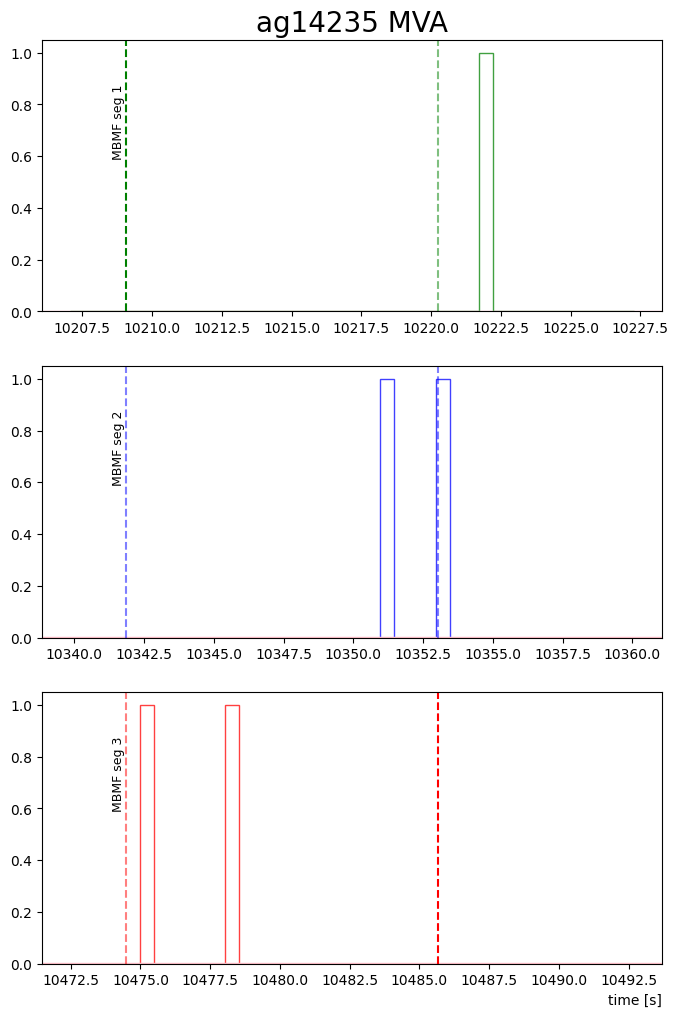

In [11]:
binning = np.array([40])
print(binning)

plt.figure(1, figsize = (8, 12))
plt.subplot(3,1,1)
plt.title(f"ag{runs['2025'][0].split('/')[0].replace('ag','')} MVA", fontsize = 20)
#plt.yticks(fontsize = 16)
#plt.xticks(fontsize = 16)
#plt.ylim(0,30)
TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (start_mbmf_rampdown0[0] - 2, stop_mbmf_rampdown0[0] + 7) , histtype = "step", color = "green", density = False, alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_mbmf_rampdown0[0], linestyle = "--", color = "green")
plt.axvline(stop_mbmf_rampdown0[0], linestyle = "--", color = "green", alpha = 0.5)
plt.text(start_mbmf_rampdown0[0] - .5, 0.6*maxbin, "MBMF seg 1",rotation = 90, fontsize = 9)
#plt.legend()

plt.subplot(3,1,2)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (start_mbmf_rampdown1[0] - 2, stop_mbmf_rampdown1[0] + 7) , histtype = "step", color = "blue", density = False, alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.text(start_mbmf_rampdown1[0] - .5, 0.6* maxbin, "MBMF seg 2",rotation = 90, fontsize = 9)

plt.subplot(3,1,3)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (start_mbmf_rampdown2[0] - 2, stop_mbmf_rampdown2[0] + 7) , histtype = "step", color = "red", density = False, alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_mbmf_rampdown2[0], linestyle = "--", color = "red", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown2[0], linestyle = "--", label = "", color = "red")
plt.text(start_mbmf_rampdown2[0] - 0.5, 0.6*maxbin, "MBMF seg 3",rotation = 90, fontsize = 9)
plt.xlabel("time [s]", loc = "right")
#plt.ylim(0,30)

#plt.legend( fontsize = 14, loc = "upper right")
plt.savefig(f"Ramps_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Mirror B and F three segments + QuasiTrapped

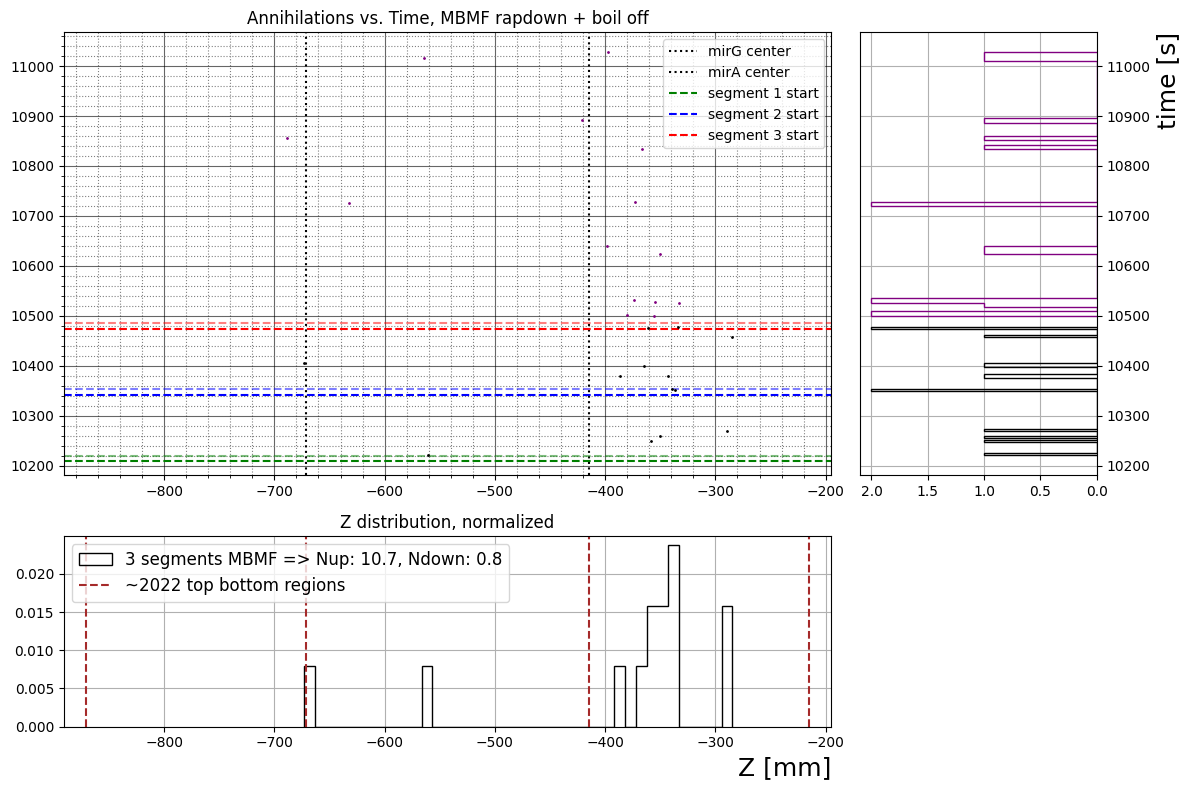

In [12]:
def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):
    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum(), Ndwn.sum()

mask   = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < stop_mbmf_rampdown2[0])
mask2 = (data["run time"] > stop_mbmf_rampdown2[0])  & (data["run time"] < waitForQuasiTrapped_stop1[0])

Nup, Ndown = NupNdown(data, start_mbmf_rampdown0[0], stop_mbmf_rampdown2[0], zmin, zmax, zgap_min, zgap_max)

Nup   -= bkg_up   * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])
Ndown -= bkg_down * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)
ax1.errorbar(data["Z"][mask2], data["run time"][mask2] , color = "purple", marker = ".", linestyle = "", markersize = 2)
ax1.axvline(mirG_center, linestyle = "dotted", color = "black", label = "mirG center")
ax1.axvline(mirA_center, linestyle = "dotted", color = "black", label = "mirA center")
ax1.axhline(start_mbmf_rampdown0[0], linestyle = "--", label = "segment 1 start", color = "green")
ax1.axhline(stop_mbmf_rampdown0[0], linestyle = "--", color = "green", alpha = 0.5)
ax1.axhline(start_mbmf_rampdown1[0], linestyle = "--", label = "segment 2 start", color = "blue")
ax1.axhline(stop_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
ax1.axhline(start_mbmf_rampdown2[0], linestyle = "--", label = "segment 3 start", color = "red")
ax1.axhline(stop_mbmf_rampdown2[0], linestyle = "--", color = "red", alpha = 0.5)

ax1.set_title("Annihilations vs. Time, MBMF rapdown + boil off")
ax1.set_xlim(zmin-20,zmax+20)
ax1.legend()
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"3 segments MBMF => Nup: {Nup:.1f}, Ndown: {Ndown:.1f}")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)
ax2.grid()

counts, bins, _ = ax3.hist(data["run time"][mask], bins = 60, histtype = "step",  color = "black", density = False,  orientation='horizontal')
counts, bins, _ = ax3.hist(data["run time"][mask2], bins = 60, histtype = "step", color = "Purple", density = False, orientation='horizontal')
xgrid = np.linspace(bins[4], bins[-1], 100)

#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()
ax3.grid()

plt.tight_layout()
plt.show()
fig.savefig(f"MBMF_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Z pdf for the three segments

In [ ]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < stop_mbmf_rampdown0[0])
mask_seg1   = (data["run time"] > start_mbmf_rampdown1[0]) & (data["run time"] < stop_mbmf_rampdown1[0])
mask_seg2   = (data["run time"] > start_mbmf_rampdown2[0]) & (data["run time"] < stop_mbmf_rampdown2[0])

#print(stop_mbmf_rampdown0[0],start_mbmf_rampdown1[0] )

ax.set_title("Z distribution during three seg rampdown")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)

ax.hist(data["Z"][mask_seg0], 
        bins = 30, 
        range = [zmin, zmax],
        histtype = "step", 
        color = "green", 
        density = True,  
        label = f"seg 1")

ax.hist(data["Z"][mask_seg1], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "blue", 
        density = True,  
        label = f"seg 2")

ax.hist(data["Z"][mask_seg2], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "red", 
        density = True,  
        label = f"seg 3")

ax.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"Zpds_three_segments_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

In [ ]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < start_mbmf_rampdown1[0])
mask_seg1   = (data["run time"] > start_mbmf_rampdown1[0]) & (data["run time"] < start_mbmf_rampdown2[0])
mask_seg2   = (data["run time"] > start_mbmf_rampdown2[0]) & (data["run time"] < start_mbmf_rampdown2[0] + 120)

ax.set_title("Z distribution during three seg rampdown")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)

ax.hist(data["Z"][mask_seg0], 
        bins = 30, 
        range = [zmin, zmax],
        histtype = "step", 
        color = "green", 
        density = True,  
        label = f"seg 1")

ax.hist(data["Z"][mask_seg1], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "blue", 
        density = True,  
        label = f"seg 2")

ax.hist(data["Z"][mask_seg2], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "red", 
        density = True,  
        label = f"seg 3")

ax.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"Zpds_threesegmentsAndWait_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

In [ ]:
Oc_start_rampdown, Oc_stop_rampdown

mask = (data["run time"] > Oc_start_rampdown[0]) & (data["run time"] < Oc_stop_rampdown[0])

Nup, Ndown = NupNdown(data, Oc_start_rampdown[0], Oc_stop_rampdown[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (Oc_stop_rampdown[0] - Oc_start_rampdown[0])
Ndown = Ndown - bkg_down * (Oc_stop_rampdown[0] - Oc_start_rampdown[0])

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.set_title("Annihilations vs. Time, Oc Ramp Down")

ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "black", marker = ".", markersize = 3, linestyle = "")
# ax1.legend(fontsize = 20)
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

# ax1.axhline(start_mbmf_rampdown0[0], linestyle = "--", label = "mbmf[1]", color = "green")
# ax1.axhline(stop_mbmf_rampdown0[0], linestyle = "--", color = "green")

# ax1.axhline(start_mbmf_rampdown1[0], linestyle = "--", label = "mbmf[2]", color = "blue")
# ax1.axhline(stop_mbmf_rampdown1[0], linestyle = "--", color = "blue")

# ax1.axhline(start_mbmf_rampdown2[0], linestyle = "--", label = "mbmf[3]", color = "red")
# ax1.axhline(stop_mbmf_rampdown2[0], linestyle = "--", color = "red")

# ax1.axhline(start_mbmf_rampdown4[0], linestyle = "--", label = "mbmf[4] Porch", color = "purple")
# ax1.axhline(stop_mbmf_rampdown4[0], linestyle = "--", label = "End Porch", color = "black")
ax1.legend()
ax1.set_xlim(zmin-20,zmax+20)


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)

counts, bins, _ = ax3.hist(data["run time"][mask], bins = 60, histtype = "step", color = "black", density = False, orientation='horizontal')

#ax3.axhline(timecut, linestyle = "--", color = "black")
#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"Oc_RampDown{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# R, phi distributions

In [ ]:
def cart2cyl(x, y, z, degrees=False):
    """
    Versione vettoriale (accetta float o array-like) basata su NumPy.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    r = np.hypot(x, y)
    phi = np.arctan2(y, x)                   # (-π, π]
    phi = np.mod(phi, 2 * np.pi)/np.pi       # [0, 2π)

    if degrees:
        phi = np.degrees(phi)

    return phi

In [ ]:
data["phi"] = cart2cyl(data["X"], data["Y"], data["Z"])

In [ ]:
# compute the radius
mask = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < waitForQuasiTrapped_stop1[0])

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occupa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occupa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occupa 1 riga

ax1.errorbar(data["run time"][mask], data["phi"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)

ax1.set_title(r"TIME vs. $\phi$, mbmf rampdown")
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigiaax1.set_ylim(0, 2)

ax1.set_yticks([0, 0.5, 1, 1.5, 2])
ax1.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])
ax1.set_ylim(-0.1, 2.1)

#ax1.axvline(start_mbmf_rampdown[0], linestyle = "--", label = "mbmf[0]", color = "orange")
ax1.axvline(start_mbmf_rampdown0[0], linestyle = "--", label = "mbmf[1]", color = "green")
ax1.axvline(start_mbmf_rampdown1[0], linestyle = "--", label = "mbmf[2]", color = "blue")
ax1.axvline(start_mbmf_rampdown2[0], linestyle = "--", label = "mbmf[3]", color = "red")
ax1.axvline(waitForQuasiTrapped_start1[0], linestyle = "--", label = "Boil off", color = "Purple")
ax1.legend()


ax2.hist(data["run time"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.set_title("Time distribution [s]")
ax2.set_xlabel("time [s]", loc = "right", fontsize = 18)
ax2.legend(fontsize = 12)
#ax2.axvline(start_mbmf_rampdown[0], linestyle = "--")
ax2.axvline(start_mbmf_rampdown0[0], linestyle = "--")
ax2.axvline(start_mbmf_rampdown1[0], linestyle = "--")
ax2.axvline(start_mbmf_rampdown2[0], linestyle = "--")

counts, bins, _ = ax3.hist(data["phi"][mask], bins = 50, range = (0,2),  histtype = "step", color = "black", density = False, orientation='horizontal', label = "ALL")

mask_mbmf1 = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < start_mbmf_rampdown1[0])
mask_mbmf2 = (data["run time"] > start_mbmf_rampdown1[0]) & (data["run time"] < start_mbmf_rampdown2[0])
mask_mbmf3 = (data["run time"] > start_mbmf_rampdown2[0]) & (data["run time"] < stop_mbmf_rampdown2[0])

#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf1], bins = 25, range = (0,100), histtype = "step", color = "green", density = False, orientation='horizontal', label = "mbmf[1]")
#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf2], bins = 25, range = (0,100), histtype = "step", color = "blue", density = False, orientation='horizontal', label = "mbmf[2]")
#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf3], bins = 25, range = (0,100), histtype = "step", color = "red", density = False, orientation='horizontal', label = "mbmf[3]")
#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf4], bins = 25, range = (0,100), histtype = "step", color = "purple", density = False, orientation='horizontal', label = "mbmf[4]")

print(len(bins[:-1]), len(counts))
ax3.set_ylim(-0.1, 2.1)
ax3.set_ylabel("phi", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")

ax3.set_yticks([0, 0.5, 1, 1.5, 2])
ax3.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])

ax3.invert_xaxis()
ax3.legend()

plt.tight_layout()
plt.show()
fig.savefig(f"TimevsPHI_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Glue the result in the Notebook and retrieve them later

In [ ]:
def ScurveExtractor(label, data, tstart, tstop, zcuts):
    
    Nup, Ndown = NupNdown(data, tstart, tstop, zcuts.zmin, zcuts.zmax, zcuts.zgap_min, zcuts.zgap_max)
    Nup        = Nup - bkg_up * (tstop - tstart)
    Ndown      = Ndown - bkg_down * (tstop - tstart)

    if((Nup + Ndown) > 0):
        S = (Ndown - Nup)/(Nup + Ndown)
    else:
        S = np.nan
    
    result = S
    
    if((Nup + Ndown) > 0):
        dResult = np.sqrt(abs(1 - S**2)/(Nup + Ndown))
    else:
        dResult = np.nan

    sb.glue(label, [result, dResult])

    print(label, f"Nup {Nup:.1f}, Ndown {Ndown:.1f}")
    
    return 0

In [ ]:
Nup, Ndown = NupNdown(data, start_mbmf_rampdown0[0], stop_mbmf_rampdown2[0], zmin, zmax, zgap_min, zgap_max)
Nup        = Nup - bkg_up * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])
Ndown      = Ndown - bkg_down * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])
S = (Ndown - Nup)/(Nup + Ndown)
result = S
dResult = np.sqrt(abs(1 - S**2)/(Nup + Ndown))
sb.glue("my_result", [result, dResult])

###--------------------
ScurveExtractor("ramp1", data, start_mbmf_rampdown0[0], stop_mbmf_rampdown0[0], ZCUTS) # first segment
ScurveExtractor("ramp2", data, start_mbmf_rampdown1[0], stop_mbmf_rampdown1[0], ZCUTS) # second segment
ScurveExtractor("ramp3", data, start_mbmf_rampdown2[0], stop_mbmf_rampdown2[0], ZCUTS) # third segment

###--------------------
ScurveExtractor("ramp1pluswait", data, start_mbmf_rampdown0[0], start_mbmf_rampdown1[0], ZCUTS) # first segment
ScurveExtractor("ramp2pluswait", data, start_mbmf_rampdown1[0], start_mbmf_rampdown2[0], ZCUTS) # second segment
ScurveExtractor("ramp3pluswait", data, start_mbmf_rampdown2[0], waitForQuasiTrapped_start1[0], ZCUTS) # third segment

###--------------------
ScurveExtractor("ramp1onlywait", data, stop_mbmf_rampdown0[0], start_mbmf_rampdown1[0], ZCUTS) # first segment
ScurveExtractor("ramp2onlywait", data, stop_mbmf_rampdown1[0], start_mbmf_rampdown2[0], ZCUTS) # second segment
ScurveExtractor("ramp3onlywait", data, stop_mbmf_rampdown2[0], waitForQuasiTrapped_start1[0], ZCUTS) # third segment

ScurveExtractor("boiloff", data, waitForQuasiTrapped_start1[0], waitForQuasiTrapped_stop1[0] , ZCUTS) # boil off

# Retrieve all the counts passing selection and save in the notebook
Nup, Ndown = NupNdown(data, mw_cb_start[0], stop_RampAllFinalStep[0], zmin, zmax, zgap_min, zgap_max)
sb.glue("tot_counts", [TOT_RUN_counts.sum(), Nup, Ndown])